In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Correct file path from the environment file list
file_path = '260319_GrauIAI_data.xlsx'

try:
    df = pd.read_excel(file_path)
    # Create df_clean in the GLOBAL scope
    df_clean = df.dropna(subset=['TRANSLATOR', 'MANUFACTURER_SECTOR'])
    print('Data loaded and cleaned successfully.')
except Exception as e:
    print(f'Error loading file: {e}')

def run_eda():
    if 'df_clean' not in globals():
        print('df_clean not found.')
        return
    # ... (rest of the EDA code remains the same)
    print('EDA analysis ready.')

run_eda()

Data loaded and cleaned successfully.
EDA analysis ready.


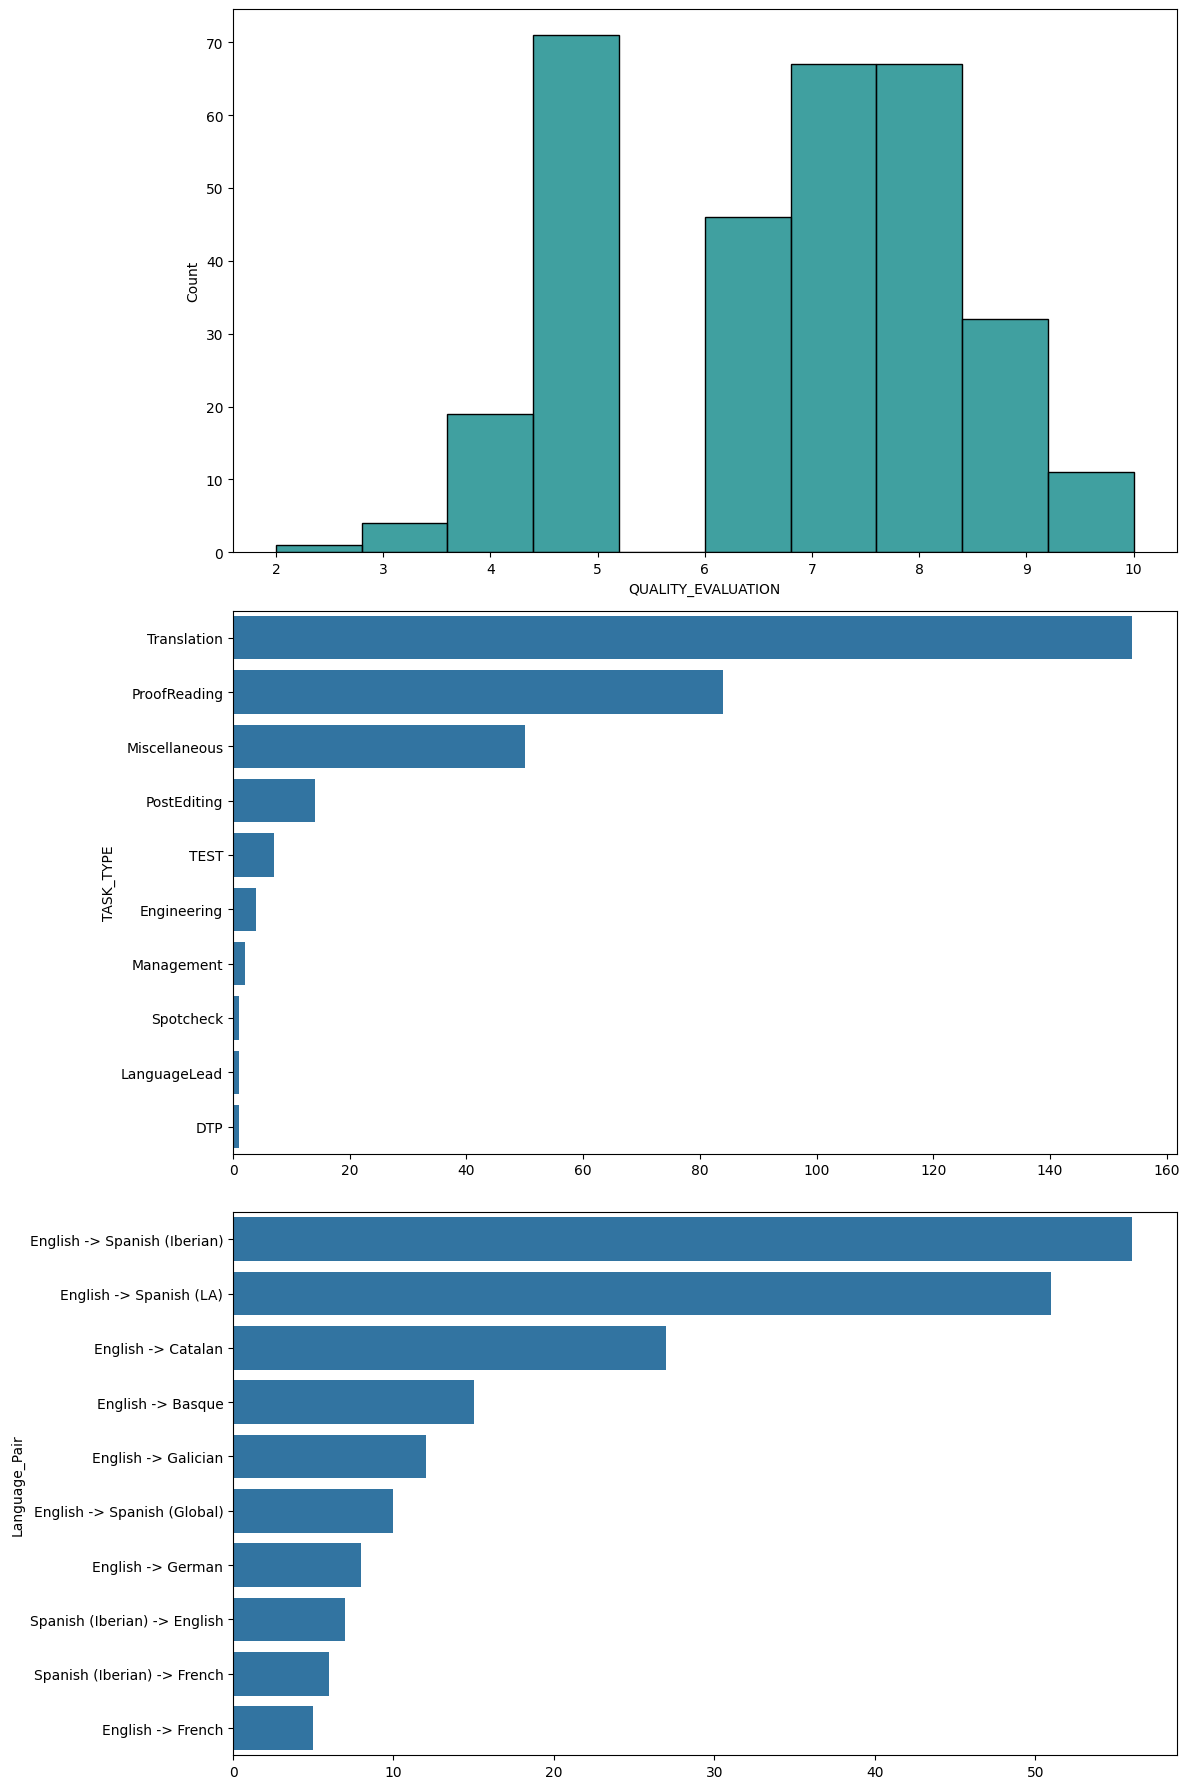

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure we are using the global df_clean
if 'df_clean' in globals():
    src_col = 'SOURCE_LANG'
    tgt_col = 'TARGET_LANG'
    qual_col = 'QUALITY_EVALUATION'
    task_col = 'TASK_TYPE'

    # Define tasks_per_translator
    tasks_per_translator = df_clean.groupby('TRANSLATOR')['TASK_ID'].count().reset_index()
    tasks_per_translator.columns = ['Translator', 'Total_Tasks']

    # Identify low volume
    low_vol_translators = tasks_per_translator[tasks_per_translator['Total_Tasks'].isin([1, 2])]['Translator']
    low_vol_df = df_clean[df_clean['TRANSLATOR'].isin(low_vol_translators)].copy()

    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 18))

    # Plot 1: Quality
    quality_data = pd.to_numeric(low_vol_df[qual_col], errors='coerce').dropna()
    if not quality_data.empty:
        sns.histplot(quality_data, bins=10, ax=ax1, color='teal')
    else:
        qual_counts = low_vol_df[qual_col].value_counts().head(10)
        sns.barplot(x=qual_counts.values, y=qual_counts.index, ax=ax1)

    # Plot 2: Task Type
    task_types = low_vol_df[task_col].value_counts().head(10)
    sns.barplot(x=task_types.values, y=task_types.index, ax=ax2)

    # Plot 3: Languages
    low_vol_df['Language_Pair'] = low_vol_df[src_col].astype(str) + ' -> ' + low_vol_df[tgt_col].astype(str)
    lang_pairs = low_vol_df['Language_Pair'].value_counts().head(10)
    sns.barplot(x=lang_pairs.values, y=lang_pairs.index, ax=ax3)

    plt.tight_layout()
    plt.show()
else:
    print('Error: df_clean is not defined. Please run the data loading cell first.')

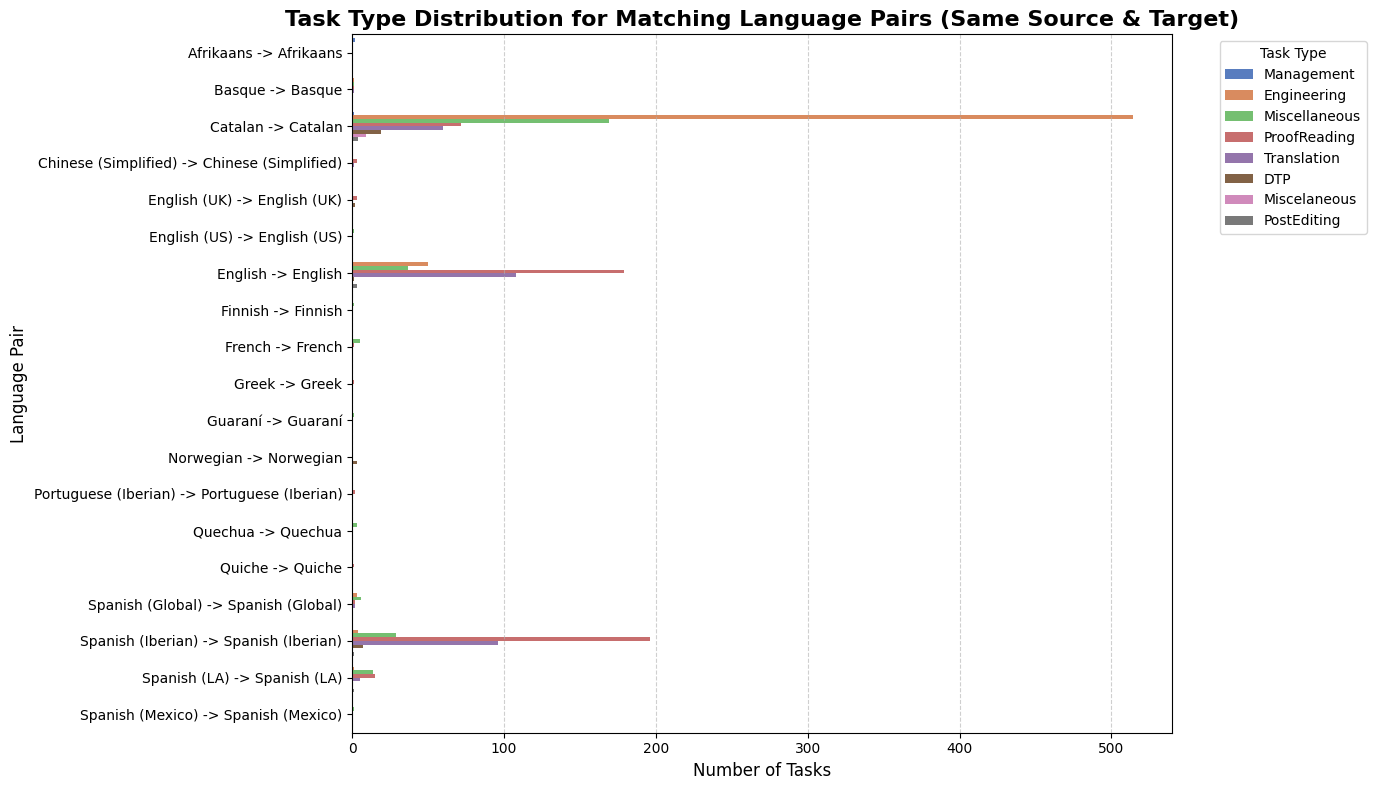

Detailed counts for matching language pairs:


,Language_Pair,TASK_TYPE,Task_Count
0,Afrikaans -> Afrikaans,Management,2
1,Basque -> Basque,Engineering,1
2,Basque -> Basque,Miscellaneous,1
3,Basque -> Basque,ProofReading,1
4,Basque -> Basque,Translation,1
6,Catalan -> Catalan,Engineering,514
9,Catalan -> Catalan,Miscellaneous,169
11,Catalan -> Catalan,ProofReading,72
12,Catalan -> Catalan,Translation,60
5,Catalan -> Catalan,DTP,19


In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Filter for matching language pairs
matching_langs_df = df_clean[df_clean['SOURCE_LANG'] == df_clean['TARGET_LANG']].copy()

if not matching_langs_df.empty:
    # FIX: Create the 'Language_Pair' column for this specific dataframe
    matching_langs_df['Language_Pair'] = matching_langs_df['SOURCE_LANG'].astype(str) + ' -> ' + matching_langs_df['TARGET_LANG'].astype(str)

    # 2. Group by Language Pair and Task Type
    matching_stats = matching_langs_df.groupby(['Language_Pair', 'TASK_TYPE']).size().reset_index(name='Task_Count')

    # 3. Plotting
    plt.figure(figsize=(14, 8))
    sns.barplot(
        data=matching_stats,
        x='Task_Count',
        y='Language_Pair',
        hue='TASK_TYPE',
        palette='muted'
    )

    plt.title('Task Type Distribution for Matching Language Pairs (Same Source & Target)', fontsize=16, fontweight='bold')
    plt.xlabel('Number of Tasks', fontsize=12)
    plt.ylabel('Language Pair', fontsize=12)
    plt.legend(title='Task Type', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(axis='x', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

    # Display summary table
    print("Detailed counts for matching language pairs:")
    display(matching_stats.sort_values(by=['Language_Pair', 'Task_Count'], ascending=[True, False]))
else:
    print('No records found where Source Language matches Target Language.')

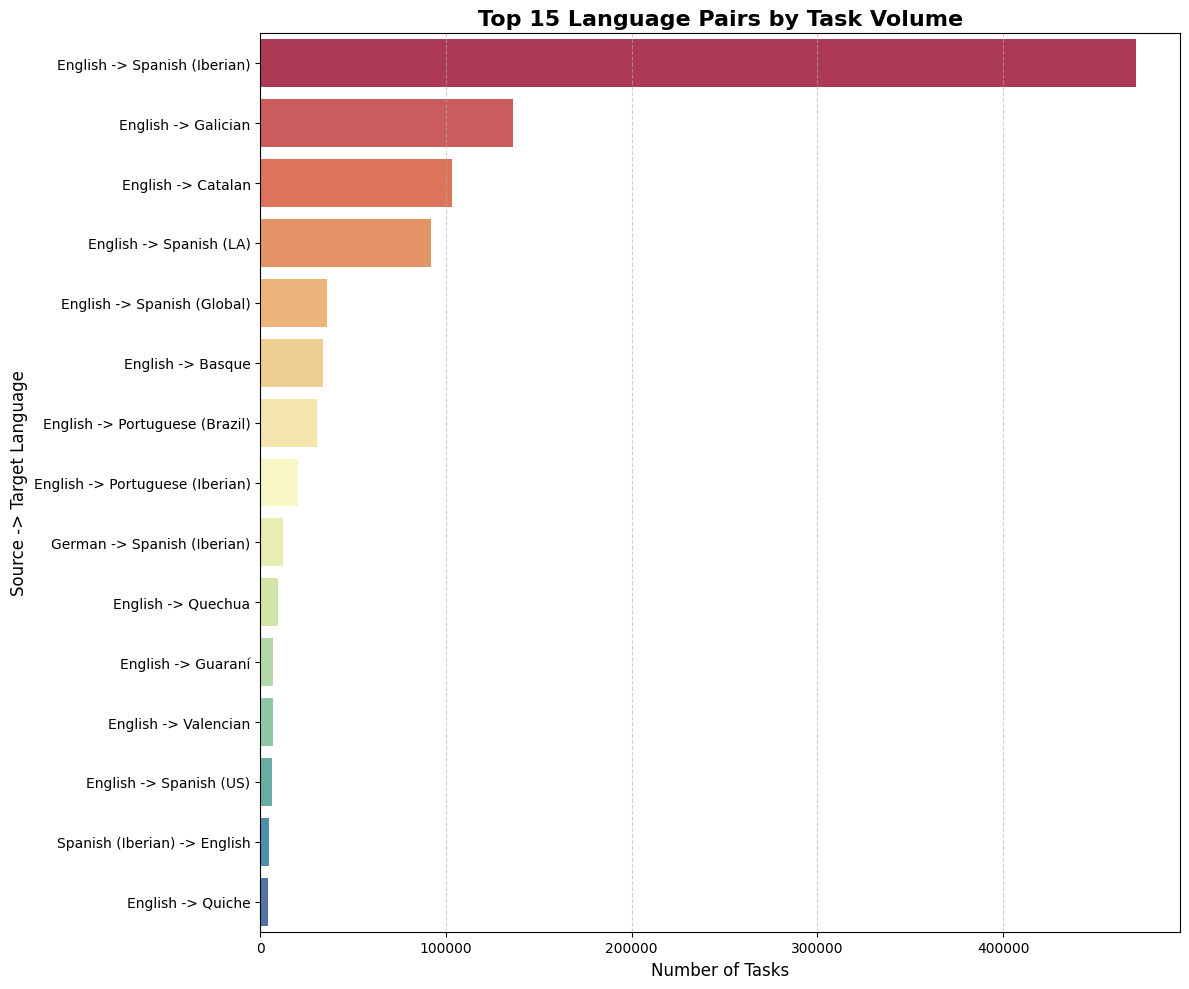

,Language_Pair,Count
0,English -> Spanish (Iberian),471597
1,English -> Galician,136330
2,English -> Catalan,103275
3,English -> Spanish (LA),91952
4,English -> Spanish (Global),35769
5,English -> Basque,33918
6,English -> Portuguese (Brazil),30693
7,English -> Portuguese (Iberian),20360
8,German -> Spanish (Iberian),12450
9,English -> Quechua,9780


In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Prepare the Language Pair column for the full dataset
# Using the column names identified in previous steps: SOURCE_LANG and TARGET_LANG
if 'SOURCE_LANG' in df_clean.columns and 'TARGET_LANG' in df_clean.columns:
    df_clean['Language_Pair'] = df_clean['SOURCE_LANG'].astype(str) + ' -> ' + df_clean['TARGET_LANG'].astype(str)

    # 2. Count occurrences and select top 15
    top_lang_pairs = df_clean['Language_Pair'].value_counts().head(15).reset_index()
    top_lang_pairs.columns = ['Language_Pair', 'Count']

    # 3. Plotting
    plt.figure(figsize=(12, 10))
    sns.barplot(
        data=top_lang_pairs,
        x='Count',
        y='Language_Pair',
        hue='Language_Pair',
        palette='Spectral',
        legend=False
    )

    plt.title('Top 15 Language Pairs by Task Volume', fontsize=16, fontweight='bold')
    plt.xlabel('Number of Tasks', fontsize=12)
    plt.ylabel('Source -> Target Language', fontsize=12)
    plt.grid(axis='x', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

    # Display summary table
    display(top_lang_pairs)
else:
    print('Error: Could not find SOURCE_LANG or TARGET_LANG columns.')

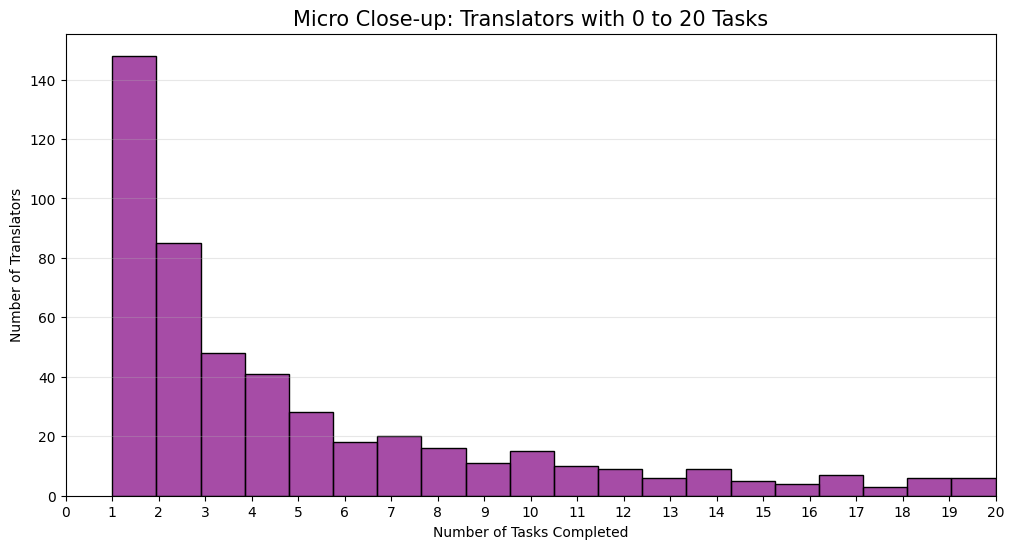

495 translators (50.4%) have completed 20 tasks or fewer.


In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filtering data for the micro close-up view (0 to 20 tasks)
tasks_0_20 = tasks_per_translator[tasks_per_translator['Total_Tasks'] <= 20]

plt.figure(figsize=(12, 6))
sns.histplot(tasks_0_20['Total_Tasks'], bins=20, kde=False, color='purple', alpha=0.7)

plt.title('Micro Close-up: Translators with 0 to 20 Tasks', fontsize=15)
plt.xlabel('Number of Tasks Completed')
plt.ylabel('Number of Translators')
plt.xlim(0, 20)
plt.xticks(range(0, 21))
plt.grid(axis='y', alpha=0.3)
plt.show()

num_0_20 = len(tasks_0_20)
percentage_0_20 = (num_0_20 / len(tasks_per_translator)) * 100
print(f"{num_0_20} translators ({percentage_0_20:.1f}%) have completed 20 tasks or fewer.")

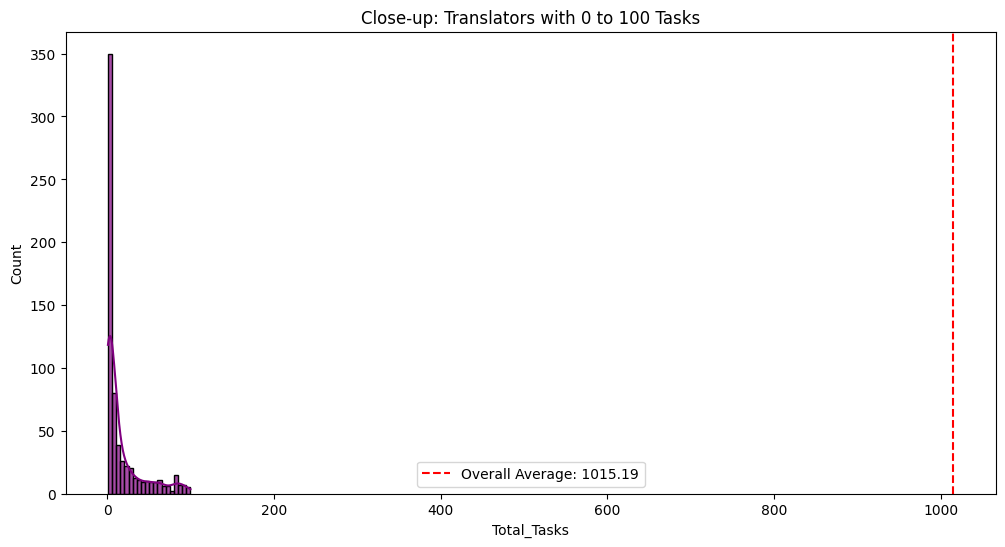

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

# FIX: Ensure avg_tasks is calculated in case 24dc9e72 wasn't run
if 'tasks_per_translator' in globals():
    avg_tasks = tasks_per_translator['Total_Tasks'].mean()
    tasks_0_100 = tasks_per_translator[tasks_per_translator['Total_Tasks'] <= 100]

    plt.figure(figsize=(12, 6))
    sns.histplot(tasks_0_100['Total_Tasks'], bins=20, kde=True, color='purple', alpha=0.7)
    plt.axvline(avg_tasks, color='red', linestyle='--', label=f'Overall Average: {avg_tasks:.2f}')
    plt.title('Close-up: Translators with 0 to 100 Tasks')
    plt.legend()
    plt.show()
else:
    print('Please run the cell that defines tasks_per_translator first.')

NameError: name 'avg_tasks' is not defined

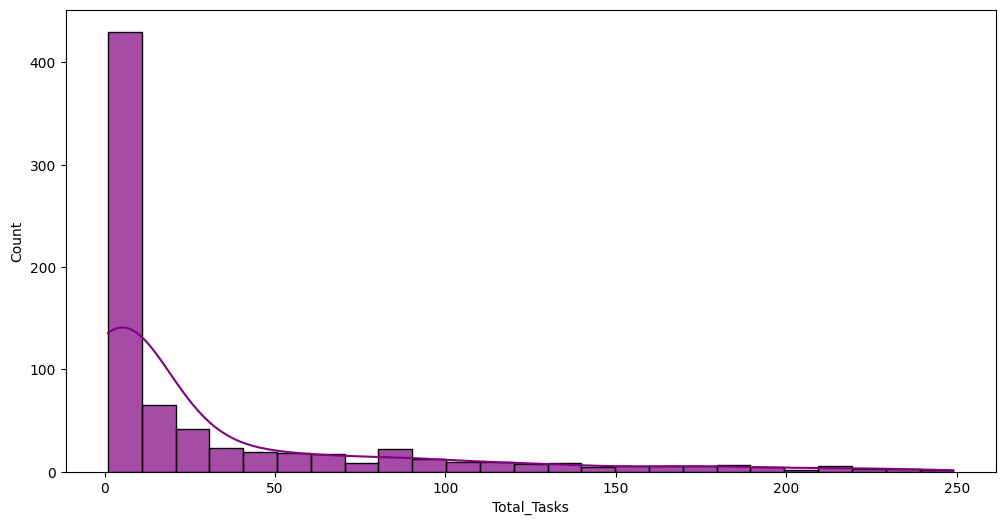

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filtering data for the close-up view (0 to 250 tasks)
tasks_filtered = tasks_per_translator[tasks_per_translator['Total_Tasks'] <= 250]

plt.figure(figsize=(12, 6))
sns.histplot(tasks_filtered['Total_Tasks'], bins=25, kde=True, color='purple', alpha=0.7)

# Add average line for reference
plt.axvline(avg_tasks, color='red', linestyle='--', label=f'Overall Average: {avg_tasks:.2f}')

plt.title('Close-up: Translators with 0 to 250 Tasks', fontsize=15)
plt.xlabel('Number of Tasks Completed')
plt.ylabel('Number of Translators')
plt.xlim(0, 250)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

num_translators_in_range = len(tasks_filtered)
percentage = (num_translators_in_range / len(tasks_per_translator)) * 100
print(f"{num_translators_in_range} translators ({percentage:.1f}%) fall within the 0-250 tasks range.")

Average tasks per translator: 1015.19
Highest number of tasks by one translator: 65209


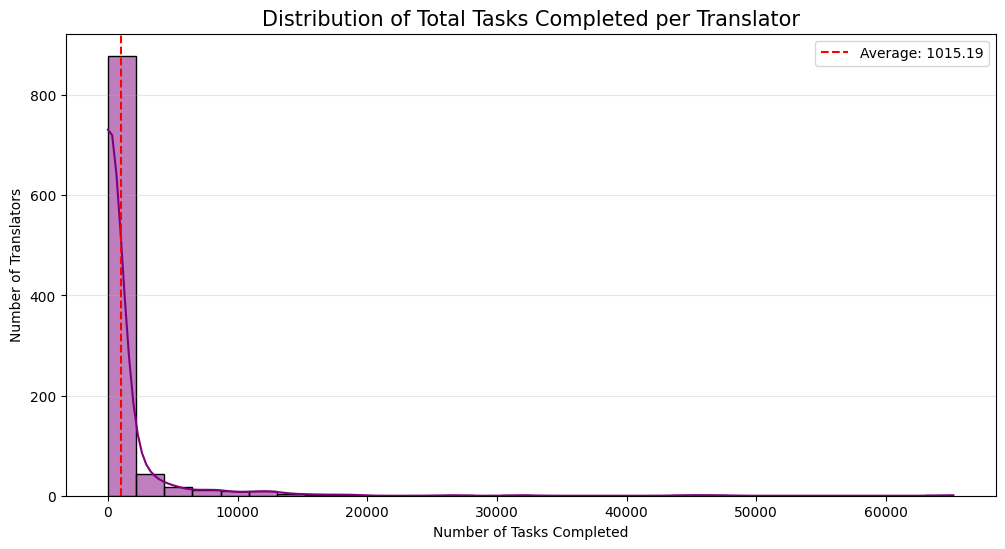


Top 10 Translators by Task Volume:


,Translator,Total_Tasks
522,Isaias Venancio,65209
971,Xoana,46436
439,Gala,44533
512,Inocencio Lucas,31950
240,Casiano,26149
721,Markel,18538
782,Nieves Leocadia,18375
167,Ascension,17036
801,Oscar,16064
669,Luis Felipe,15122


In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calculate tasks per translator
tasks_per_translator = df_clean.groupby('TRANSLATOR')['TASK_ID'].count().reset_index()
tasks_per_translator.columns = ['Translator', 'Total_Tasks']

# 2. Stats for context
avg_tasks = tasks_per_translator['Total_Tasks'].mean()
max_tasks = tasks_per_translator['Total_Tasks'].max()

print(f"Average tasks per translator: {avg_tasks:.2f}")
print(f"Highest number of tasks by one translator: {max_tasks}")

# 3. Plotting the distribution of productivity
plt.figure(figsize=(12, 6))
sns.histplot(tasks_per_translator['Total_Tasks'], bins=30, kde=True, color='purple')

plt.axvline(avg_tasks, color='red', linestyle='--', label=f'Average: {avg_tasks:.2f}')
plt.title('Distribution of Total Tasks Completed per Translator', fontsize=15)
plt.xlabel('Number of Tasks Completed')
plt.ylabel('Number of Translators')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

# Show the top 10 most active translators
print("\nTop 10 Translators by Task Volume:")
display(tasks_per_translator.sort_values('Total_Tasks', ascending=False).head(10))

Using column: HOURS for workload analysis
Average total hours per translator: 1752.60
Median total hours per translator: 133.93


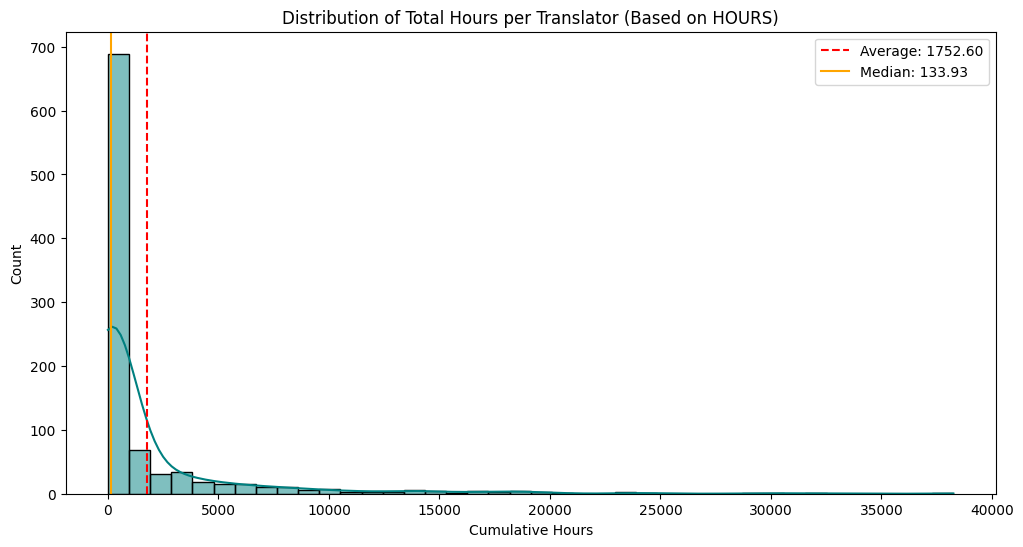

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Using 'HOURS' as the work estimation column based on the dataset structure
found_col = 'HOURS'

if found_col in df_clean.columns:
    print(f'Using column: {found_col} for workload analysis')
    # Drop missing values for estimation
    df_forecast = df_clean.dropna(subset=[found_col]).copy()

    # Aggregate total hours per translator
    time_per_translator = df_forecast.groupby('TRANSLATOR')[found_col].sum().reset_index()
    time_per_translator.columns = ['Translator', 'Total_Hours_Accumulated']

    # Filter out zero-hour records
    time_filtered = time_per_translator[time_per_translator['Total_Hours_Accumulated'] > 0]

    # Stats
    avg_hours = time_filtered['Total_Hours_Accumulated'].mean()
    median_hours = time_filtered['Total_Hours_Accumulated'].median()

    print(f'Average total hours per translator: {avg_hours:.2f}')
    print(f'Median total hours per translator: {median_hours:.2f}')

    # Plot the distribution
    plt.figure(figsize=(12, 6))
    sns.histplot(time_filtered['Total_Hours_Accumulated'], bins=40, kde=True, color='teal')
    plt.axvline(avg_hours, color='red', linestyle='--', label=f'Average: {avg_hours:.2f}')
    plt.axvline(median_hours, color='orange', linestyle='-', label=f'Median: {median_hours:.2f}')
    plt.title(f'Distribution of Total Hours per Translator (Based on {found_col})')
    plt.xlabel('Cumulative Hours')
    plt.legend()
    plt.show()
else:
    print(f'Error: {found_col} column not found.')

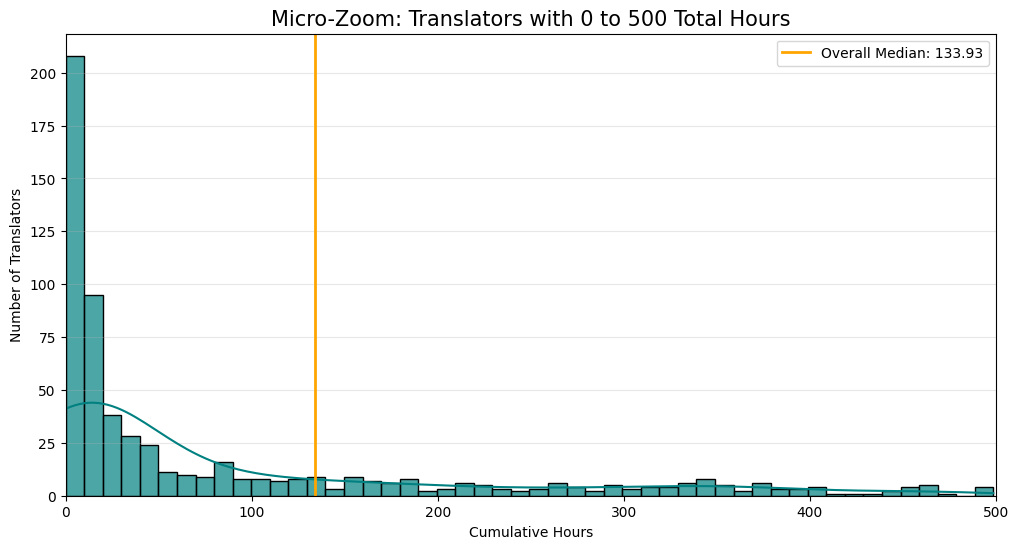

620 translators (65.3%) fall within the 0-500 hours range.


In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

if 'time_filtered' in globals():
    # Filter data for the requested micro-range
    micro_zoom_df = time_filtered[time_filtered['Total_Hours_Accumulated'] <= 500]

    plt.figure(figsize=(12, 6))
    sns.histplot(micro_zoom_df['Total_Hours_Accumulated'], bins=50, kde=True, color='teal', alpha=0.7)

    # Add median for context as it falls within this range
    plt.axvline(median_hours, color='orange', linestyle='-', linewidth=2, label=f'Overall Median: {median_hours:.2f}')

    plt.title('Micro-Zoom: Translators with 0 to 500 Total Hours', fontsize=15)
    plt.xlabel('Cumulative Hours')
    plt.ylabel('Number of Translators')
    plt.xlim(0, 500)
    plt.legend()
    plt.grid(axis='y', alpha=0.3)
    plt.show()

    num_in_micro = len(micro_zoom_df)
    pct_in_micro = (num_in_micro / len(time_filtered)) * 100
    print(f'{num_in_micro} translators ({pct_in_micro:.1f}%) fall within the 0-500 hours range.')
else:
    print('Please run the workload analysis cell first.')

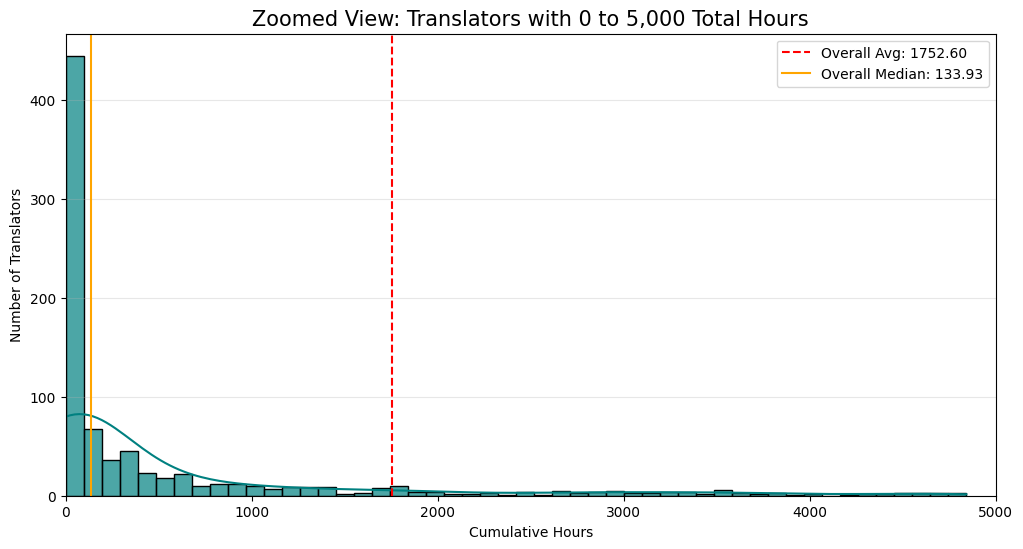

845 translators (89.0%) fall within the 0-5,000 hours range.


In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

if 'time_filtered' in globals():
    # Filter data for the requested range
    zoom_df = time_filtered[time_filtered['Total_Hours_Accumulated'] <= 5000]

    plt.figure(figsize=(12, 6))
    sns.histplot(zoom_df['Total_Hours_Accumulated'], bins=50, kde=True, color='teal', alpha=0.7)

    # Add average and median from the original full dataset for context
    plt.axvline(avg_hours, color='red', linestyle='--', label=f'Overall Avg: {avg_hours:.2f}')
    plt.axvline(median_hours, color='orange', linestyle='-', label=f'Overall Median: {median_hours:.2f}')

    plt.title('Zoomed View: Translators with 0 to 5,000 Total Hours', fontsize=15)
    plt.xlabel('Cumulative Hours')
    plt.ylabel('Number of Translators')
    plt.xlim(0, 5000)
    plt.legend()
    plt.grid(axis='y', alpha=0.3)
    plt.show()

    num_in_zoom = len(zoom_df)
    pct_in_zoom = (num_in_zoom / len(time_filtered)) * 100
    print(f'{num_in_zoom} translators ({pct_in_zoom:.1f}%) fall within the 0-5,000 hours range.')
else:
    print('Please run the workload analysis cell first to define the data.')

Average translators per sector: 366.67


/tmp/ipykernel_2652/1134244204.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


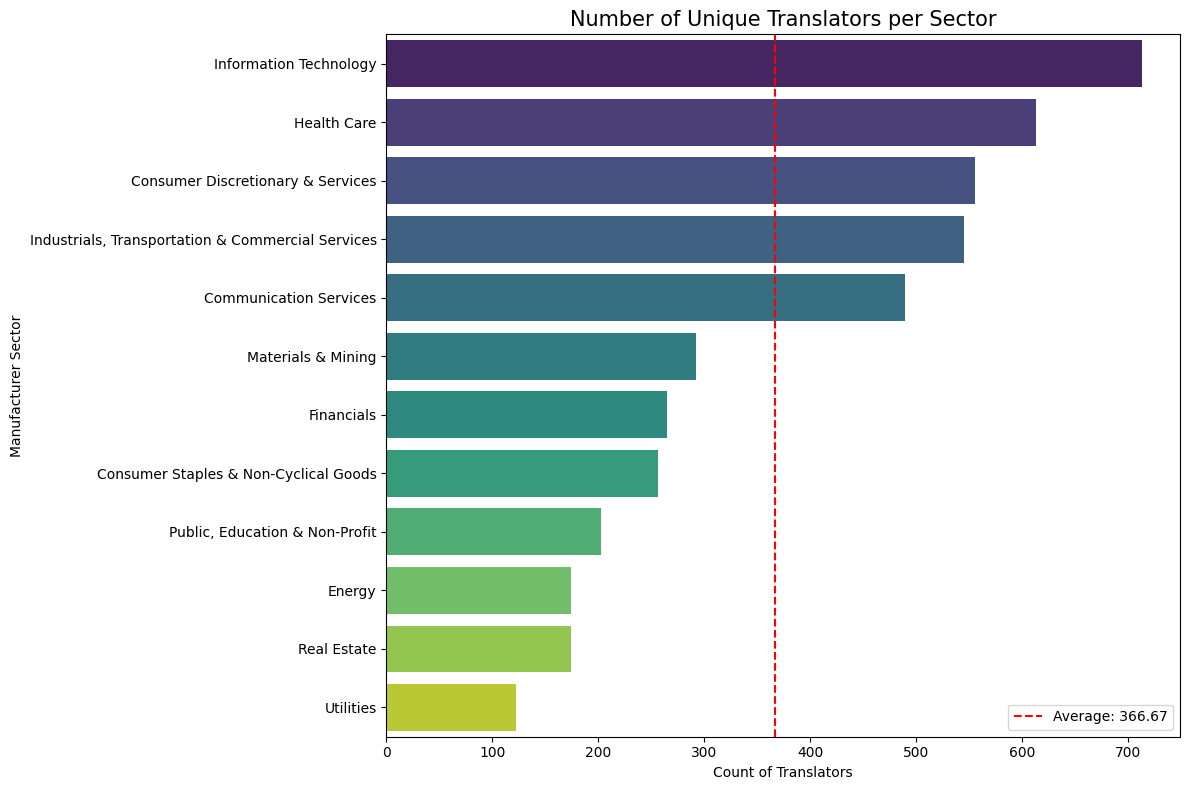

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# FIX: Use the global df_clean instead of trying to reload a missing file
if 'df_clean' in globals():
    # 2. Calculate Translators per Sector
    translators_per_sector = df_clean.groupby('MANUFACTURER_SECTOR')['TRANSLATOR'].nunique().reset_index()
    translators_per_sector.columns = ['Sector', 'Unique_Translators']

    # 3. Stats
    avg_translators = translators_per_sector['Unique_Translators'].mean()
    print(f"Average translators per sector: {avg_translators:.2f}")

    # 4. Plot
    plt.figure(figsize=(12, 8))
    sns.barplot(
        data=translators_per_sector.sort_values('Unique_Translators', ascending=False),
        y='Sector',
        x='Unique_Translators',
        palette='viridis'
    )

    plt.axvline(avg_translators, color='red', linestyle='--', label=f'Average: {avg_translators:.2f}')
    plt.title('Number of Unique Translators per Sector', fontsize=15)
    plt.xlabel('Count of Translators')
    plt.ylabel('Manufacturer Sector')
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("Error: df_clean is not defined. Please run the first cell (tyd45DvNXbnl) to load the data.")